# What actually wins on the Kaggriculture ladder, read from the replays

Most reads on this competition explain the crop economics or hand you a baseline agent. This one recomputes
the meta in front of you from the raw episode replays, so every number below comes from parsing the actual
720 turn games, not from the game manual. Each episode is one ranked match between two submitted agents. From
its replay I read what each side actually did, tag each side by its agent name, and read the winner from the
final profit. Aggregate a day of ladder games and you get the real question answered: not which crop pays
most on paper, but what the farms that actually win do differently from the farms that lose.

Fork it, point it at another day, and it recomputes. Every archetype, win rate, and strategy number is
parsed live from the logs, with no pasted figures and no leaderboard claim.

In [1]:
import os, glob, json, re, time, random
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
INK = "#1b2a4a"; ACC = "#c1440e"; ACC2 = "#1f6f8b"; GD = "#c29a22"; MUT = "#8a94a6"

def find_dir(must_digit_json=True):
    for d in sorted(glob.glob("/kaggle/input/*")) + ["D:/kaggle/scratchpad/kagg"]:
        js = [p for p in glob.glob(os.path.join(d, "*.json")) if os.path.basename(p)[:-5].isdigit()]
        if not js:
            js = [p for p in glob.glob(os.path.join(d, "**", "*.json"), recursive=True)
                  if os.path.basename(p)[:-5].isdigit()]
        if js:
            return os.path.dirname(js[0])
    return None
def find_one(name):
    for p in glob.glob(f"/kaggle/input/**/{name}", recursive=True) + glob.glob(f"D:/kaggle/**/{name}", recursive=True):
        return p
    return None

epdir = find_dir()
assert epdir is not None, "no numbered replay json folder found under /kaggle/input"
files = sorted(p for p in glob.glob(os.path.join(epdir, "*.json")) if os.path.basename(p)[:-5].isdigit())
CAP = 300                       # replays are ~25MB each; a seeded sample of the day keeps the run tractable
if len(files) > CAP:
    random.seed(0); files = sorted(random.sample(files, CAP))
_m = re.search(r"(\d{4}-\d{2}-\d{2})", epdir or ""); DAY = _m.group(1) if _m else "unknown"
print("replay dir:", epdir, "| day:", DAY, "| games to parse:", len(files))

replay dir: /kaggle/input/kaggriculture-episodes-2026-08-07 | day: 2026-08-07 | games to parse: 300


In [2]:
# each replay: rewards = [profit0, profit1] (winner = higher), info.TeamNames = the two agents,
# steps[i][seat].action = {farmer:[move], hands:[[op,...]], market:[[op,...]]} for 720 turns
CROP_KEYS = ["STRAWBERRY", "WHEAT", "MELON", "CARROT"]
def parse_replay(path):
    try:
        d = json.load(open(path, encoding="utf-8"))
    except Exception:
        return None
    rew = d.get("rewards") or []
    if len(rew) != 2 or rew[0] is None or rew[1] is None or rew[0] == rew[1]:
        return None                                   # unfinished or tied games are dropped
    names = (d.get("info") or {}).get("TeamNames") or ["?", "?"]
    winner = 0 if rew[0] > rew[1] else 1
    F = [dict(crops=Counter(), plant=0, sell=0, hire=0, buy_animal=0, buy_land=0, fert=0, harvest=0, water=0)
         for _ in range(2)]
    for st in d.get("steps", []):
        if not isinstance(st, list):
            continue
        for seat in range(min(2, len(st))):
            a = (st[seat] or {}).get("action") or {}
            for h in a.get("hands") or []:
                if not h:
                    continue
                op = h[0]
                if op == "PLANT":
                    F[seat]["plant"] += 1
                    if len(h) > 1: F[seat]["crops"][h[1]] += 1
                elif op == "COLLECT_FERTILIZER": F[seat]["fert"] += 1
                elif op == "HARVEST": F[seat]["harvest"] += 1
                elif op == "WATER": F[seat]["water"] += 1
            for mk in a.get("market") or []:
                if not mk:
                    continue
                op = mk[0]
                if op == "SELL": F[seat]["sell"] += 1
                elif op == "HIRE": F[seat]["hire"] += 1
                elif op == "BUY_ANIMAL": F[seat]["buy_animal"] += 1
                elif op == "BUY_LAND": F[seat]["buy_land"] += 1
    rows = []
    for seat in range(2):
        f = F[seat]
        rows.append(dict(agent=str(names[seat])[:28], win=int(seat == winner), score=float(rew[seat]),
                         top_crop=(f["crops"].most_common(1)[0][0] if f["crops"] else "none"),
                         plant=f["plant"], sell=f["sell"], hire=f["hire"], buy_animal=f["buy_animal"],
                         buy_land=f["buy_land"], fert=f["fert"], harvest=f["harvest"]))
    return rows

t0 = time.time(); rows = []
for k, p in enumerate(files, 1):
    r = parse_replay(p)
    if r: rows.extend(r)
    if k % 50 == 0:
        print(f"  {k}/{len(files)} replays, {len(rows)//2} decisive, {round(time.time()-t0)}s", flush=True)
sides = pd.DataFrame(rows)
games = len(sides) // 2
print(f"parsed {games} decisive games ({len(sides)} sides) in {round(time.time()-t0)}s")
print("distinct agents seen:", sides["agent"].nunique())

  50/300 replays, 41 decisive, 33s
  100/300 replays, 91 decisive, 63s
  150/300 replays, 141 decisive, 93s
  200/300 replays, 188 decisive, 124s
  250/300 replays, 234 decisive, 154s
  300/300 replays, 278 decisive, 185s
parsed 278 decisive games (556 sides) in 185s
distinct agents seen: 71


## 0. The ladder at a glance

One picture first: the agents with the strongest win rates on this day, sampled from the replays. The rest
of the notebook takes this apart, one falsifiable question per figure, every number recomputed live.

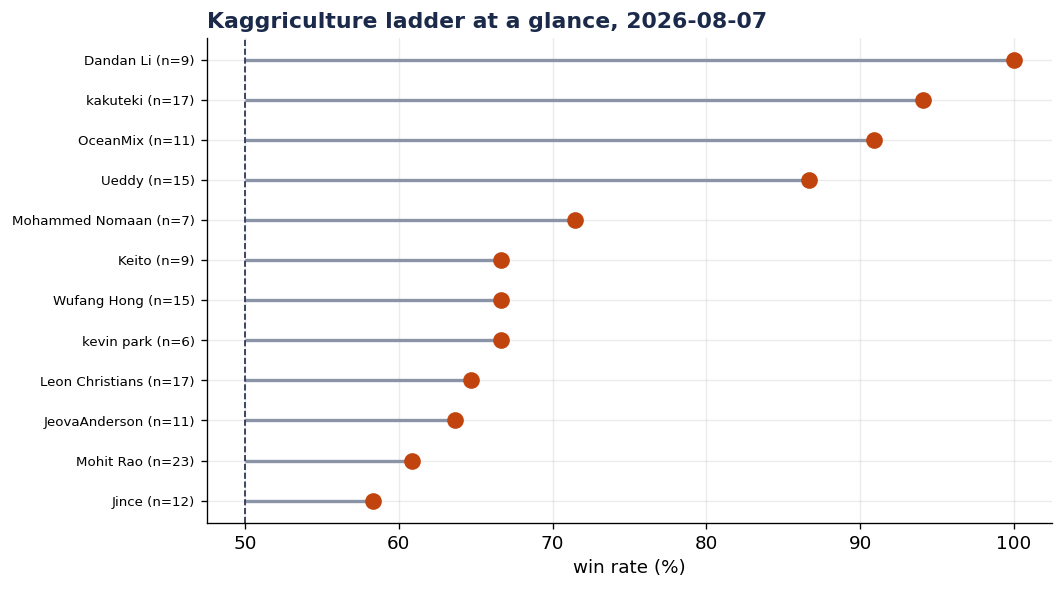

In [3]:
def wilson(w, n, z=1.96):
    if n == 0: return (0, 0, 0)
    p = w/n; d = 1 + z*z/n; c = (p + z*z/(2*n))/d; h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return p, c-h, c+h
MIN_G = 1 if games < 50 else max(6, len(sides)//200)
FEAT = ["plant", "sell", "hire", "harvest", "fert", "buy_animal", "buy_land"]
_gg = sides.groupby("agent"); _hr = []
for a, sub in _gg:
    n = len(sub)
    if n < MIN_G: continue
    p, lo, hi = wilson(int(sub.win.sum()), n); _hr.append((a, p, n))
H = pd.DataFrame(_hr, columns=["agent", "winrate", "games"]).sort_values("winrate").tail(12)
if len(H):
    fig, ax = plt.subplots(figsize=(9, max(3.2, 0.42*len(H))))
    ax.hlines(range(len(H)), 50, H.winrate*100, color=MUT, lw=2)
    ax.plot(H.winrate*100, range(len(H)), "o", color=ACC, ms=9)
    ax.axvline(50, color=INK, lw=1, ls="--")
    ax.set_yticks(range(len(H)), [f"{a[:24]} (n={n})" for a, n in zip(H.agent, H.games)], fontsize=8)
    ax.set_xlabel("win rate (%)")
    ax.set_title(f"Kaggriculture ladder at a glance, {DAY}", color=INK, loc="left", fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("too few games in this sample for the at-a-glance view (renders on the full daily dump)")

## 1. The agent tier list

Every game has two sides, each an agent. Here is each agent's win rate across all its games, with a Wilson
interval so you can see which leads are real and which are small sample noise. This is the ladder as the
replays actually played out, not the public leaderboard rating.

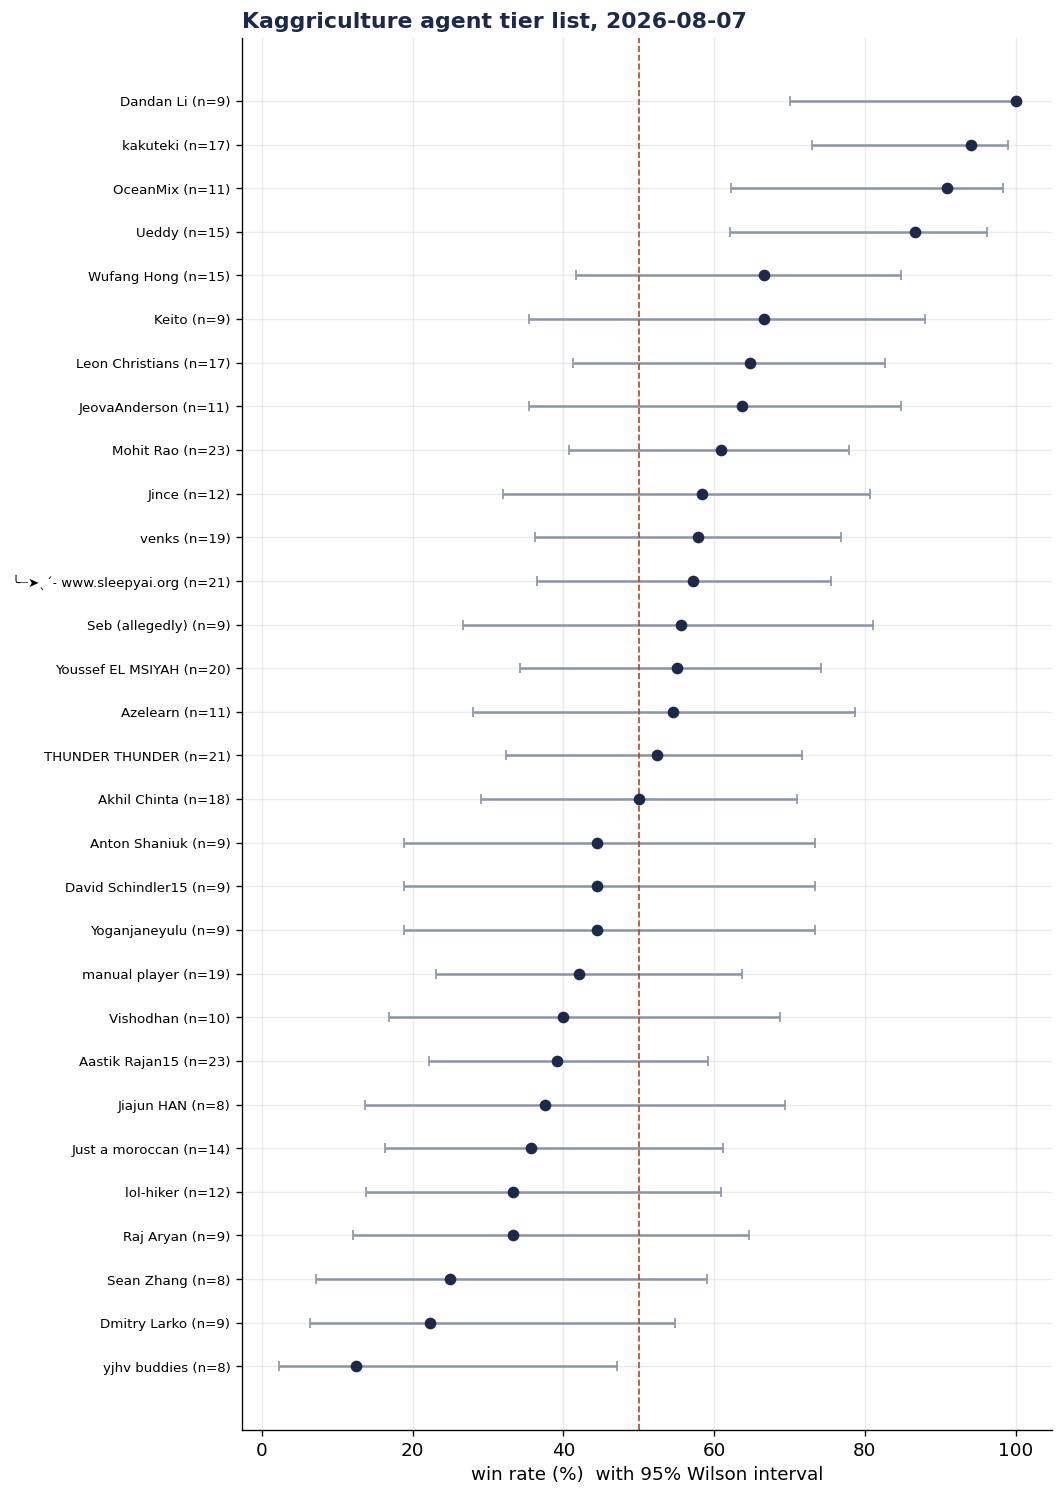

                  agent  games  winrate    lo    hi  avg_score
              Dandan Li      9    1.000 0.701 1.000  90727.667
               kakuteki     17    0.941 0.730 0.990  78308.118
               OceanMix     11    0.909 0.623 0.984 114273.455
                  Ueddy     15    0.867 0.621 0.963  91345.867
                  Keito      9    0.667 0.354 0.879 107332.111
            Wufang Hong     15    0.667 0.417 0.848 108410.933
        Leon Christians     17    0.647 0.413 0.827  98601.353
          JeovaAnderson     11    0.636 0.354 0.848 119237.636
              Mohit Rao     23    0.609 0.408 0.778 102650.957
                  Jince     12    0.583 0.320 0.807  81692.000
                  venks     19    0.579 0.363 0.769 116250.158
╰┈➤ˎˊ˗ www.sleepyai.org     21    0.571 0.365 0.755 105589.857
        Seb (allegedly)      9    0.556 0.267 0.811  87658.333
      Youssef EL MSIYAH     20    0.550 0.342 0.742 110971.400
               Azelearn     11    0.545 0.280 0.787 123

In [4]:
def wilson(w, n, z=1.96):
    if n == 0: return (0, 0, 0)
    p = w / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d; h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return p, c-h, c+h
g = sides.groupby("agent")
rec = []
for a, sub in g:
    w, n = int(sub["win"].sum()), len(sub)
    p, lo, hi = wilson(w, n)
    rec.append(dict(agent=a, games=n, winrate=p, lo=lo, hi=hi, avg_score=sub["score"].mean()))
T = pd.DataFrame(rec)
T = T[T["games"] >= max(8, T["games"].quantile(0.5))].sort_values("winrate")
fig, ax = plt.subplots(figsize=(9, max(4, 0.42*len(T))))
ax.errorbar(T["winrate"]*100, range(len(T)), xerr=[(T.winrate-T.lo)*100, (T.hi-T.winrate)*100],
            fmt="o", color=INK, ecolor=MUT, capsize=3)
ax.axvline(50, color=ACC, lw=1, ls="--")
ax.set_yticks(range(len(T)), [f"{a[:24]} (n={n})" for a, n in zip(T.agent, T.games)], fontsize=8)
ax.set_xlabel("win rate (%)  with 95% Wilson interval")
ax.set_title(f"Kaggriculture agent tier list, {DAY}", color=INK, loc="left", fontweight="bold")
plt.tight_layout(); plt.show()
print(T.sort_values("winrate", ascending=False).round(3).to_string(index=False))

## 2. Do winners just do more? Mostly not

For every side we counted the real moves: how much it planted, sold on the market, hired farm hands, bought
animals and land, and collected fertilizer over the season, then averaged the winning side against the
losing side of the same games. The honest result is the interesting one. The counts almost match: winners
and losers plant, sell, hire, harvest and fertilise about equally, and the winners actually plant slightly
less. So on this day the edge is not raw activity. Both sides stay busy for the full 720 turns; what
separates them is what they plant and how efficiently they run it, which the next two sections get at. Read
these bars as description, not proof that any one action causes the win.

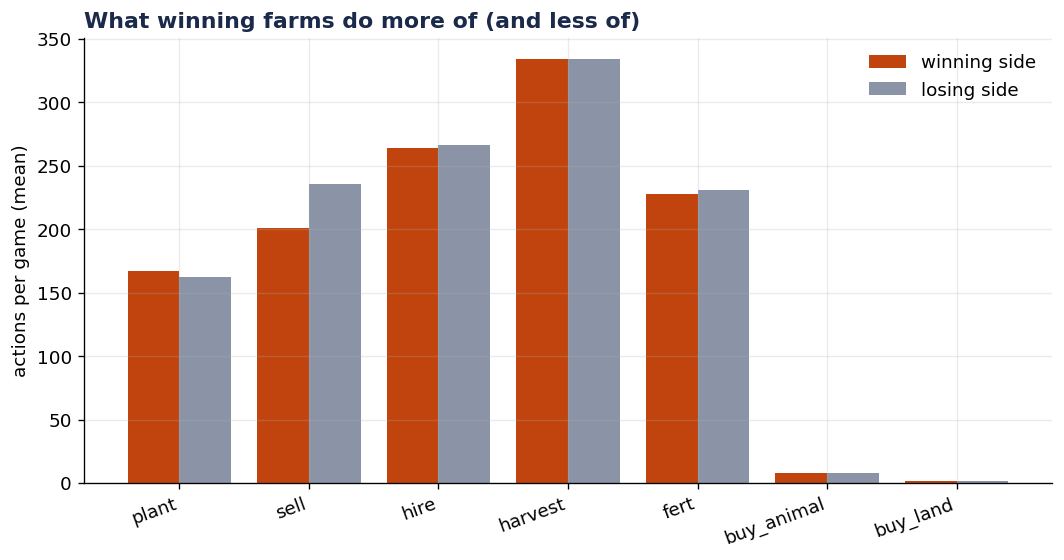

            winning  losing  ratio
plant         167.4   162.4    1.0
sell          201.2   235.8    0.8
hire          264.1   266.8    1.0
harvest       334.3   334.3    1.0
fert          227.7   231.0    1.0
buy_animal      8.1     8.1    1.0
buy_land        2.0     2.0    1.0

mean final profit: winners 106894 | losers 103685


In [5]:
feat = ["plant", "sell", "hire", "harvest", "fert", "buy_animal", "buy_land"]
win_mean = sides[sides.win == 1][feat].mean()
los_mean = sides[sides.win == 0][feat].mean()
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(feat)); w = 0.4
ax.bar(x - w/2, win_mean.values, w, label="winning side", color=ACC)
ax.bar(x + w/2, los_mean.values, w, label="losing side", color=MUT)
ax.set_xticks(x, feat, rotation=20, ha="right")
ax.set_ylabel("actions per game (mean)")
ax.set_title("What winning farms do more of (and less of)", color=INK, loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
cmp = pd.DataFrame({"winning": win_mean, "losing": los_mean})
cmp["ratio"] = (cmp["winning"] / cmp["losing"].replace(0, np.nan)).round(2)
print(cmp.round(1).to_string())
print("\nmean final profit: winners", round(sides[sides.win==1].score.mean()),
      "| losers", round(sides[sides.win==0].score.mean()))

## 3. Which crop the winners lean on

Each side has a most planted crop. This is how often each crop is the primary crop of a winning side versus
a losing side, which tells you what the field currently rewards without you having to submit an agent to find
out.

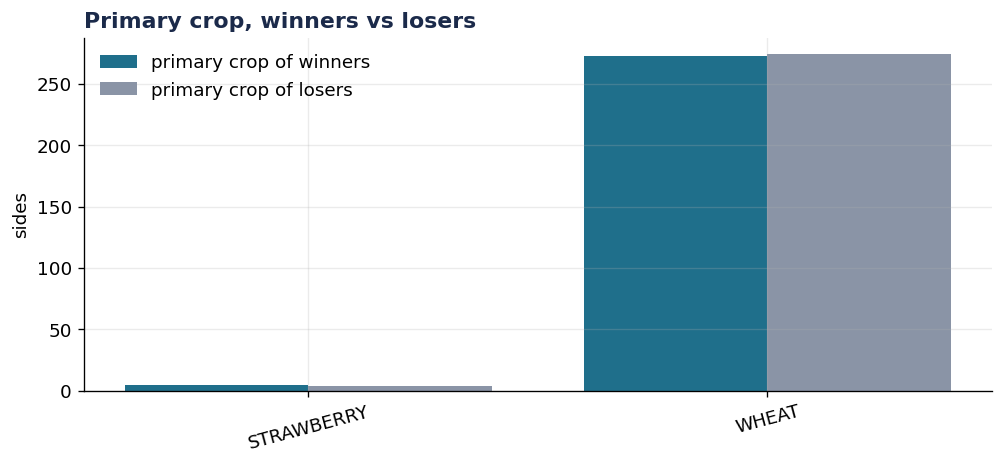

win rate when a crop is the primary crop:
  STRAWBERRY   56%  (n=9)
  WHEAT        50%  (n=547)


In [6]:
cw = sides[sides.win == 1]["top_crop"].value_counts()
cl = sides[sides.win == 0]["top_crop"].value_counts()
order = [c for c in (CROP_KEYS + ["none"]) if c in set(cw.index) | set(cl.index)]
wv = [cw.get(c, 0) for c in order]; lv = [cl.get(c, 0) for c in order]
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(order)); w = 0.4
ax.bar(x - w/2, wv, w, label="primary crop of winners", color=ACC2)
ax.bar(x + w/2, lv, w, label="primary crop of losers", color=MUT)
ax.set_xticks(x, order, rotation=15); ax.set_ylabel("sides")
ax.set_title("Primary crop, winners vs losers", color=INK, loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
wr = {c: (cw.get(c,0) / (cw.get(c,0)+cl.get(c,0)) if (cw.get(c,0)+cl.get(c,0)) else 0) for c in order}
print("win rate when a crop is the primary crop:")
for c in order: print(f"  {c:12s} {wr[c]*100:.0f}%  (n={cw.get(c,0)+cl.get(c,0)})")

## 4. The meta is heating up

The organisers publish a daily index with the top and median agent score for each day. Scores have been
climbing fast as agents improve, so a strategy that won yesterday is not a safe read for tomorrow. That is
the whole reason this is a live tracker and not a one time analysis: the target keeps moving.

manifest columns: ['date', 'daily_dataset_slug', 'daily_dataset_url', 'episode_count', 'total_bytes', 'top_avg_score', 'median_avg_score']


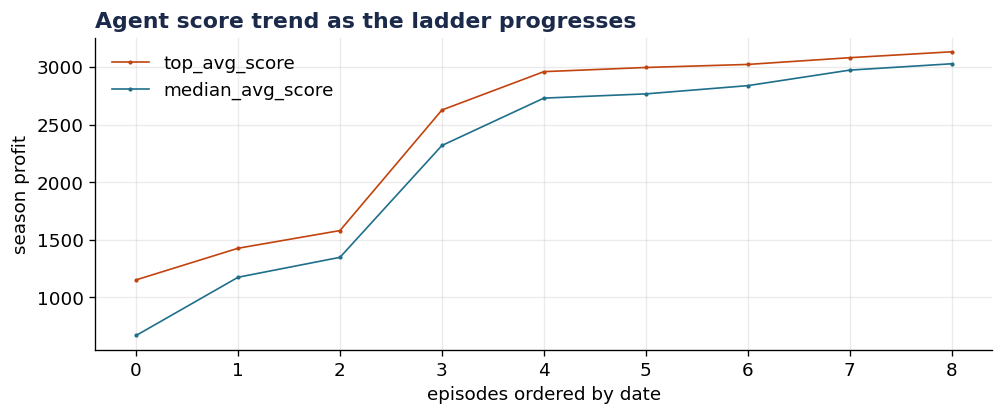

rows: 9 | plotted: ['top_avg_score', 'median_avg_score']
      date                daily_dataset_slug                                                        daily_dataset_url  episode_count  total_bytes  top_avg_score  median_avg_score
2026-07-31 kaggriculture-episodes-2026-07-31 https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-2026-07-31            928  21452054005    1427.008312       1175.253007
2026-08-01 kaggriculture-episodes-2026-08-01 https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-2026-08-01            829  21450823404    1580.555055       1348.186244
2026-08-02 kaggriculture-episodes-2026-08-02 https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-2026-08-02            793  21471097913    2627.206525       2319.161237
2026-08-03 kaggriculture-episodes-2026-08-03 https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-2026-08-03            787  21469441381    2960.127622       2730.385790
2026-08-04 kaggriculture-episodes-2026-08-04 htt

In [7]:
mpath = find_one("manifest.csv")
if mpath:
    try:
        man = pd.read_csv(mpath)
        cols = list(man.columns)
        print("manifest columns:", cols)
        datecol = next((c for c in cols if any(k in c.lower() for k in ["date", "time", "create"])), cols[0])
        num = man.select_dtypes("number").columns.tolist()
        scorecols = [c for c in num if "score" in c.lower()][:2] or num[:2]
        man = man.sort_values(datecol).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(8.5, 3.6))
        for c, cl in zip(scorecols, [ACC, ACC2, GD]):
            ax.plot(range(len(man)), man[c], ".-", color=cl, label=c, ms=3, lw=1)
        ax.set_xlabel(f"episodes ordered by {datecol}"); ax.set_ylabel("season profit")
        ax.set_title("Agent score trend as the ladder progresses", color=INK, loc="left", fontweight="bold")
        ax.legend(frameon=False)
        plt.tight_layout(); plt.show()
        print("rows:", len(man), "| plotted:", scorecols)
        print(man.tail(8).to_string(index=False))
    except Exception as e:
        print("meta trend skipped (manifest schema):", repr(e))
else:
    print("attach kaggle/kaggriculture-episodes-index to see the daily score trend")

## 5. The winning action fingerprint

Averaging every action a side takes over the season and ordering agents by win rate turns the ladder into a
fingerprint. Each row is an agent, each column an action type, the cell is that agent's mean count. The point
is which behaviours travel with a high win rate, read down the sorted rows.

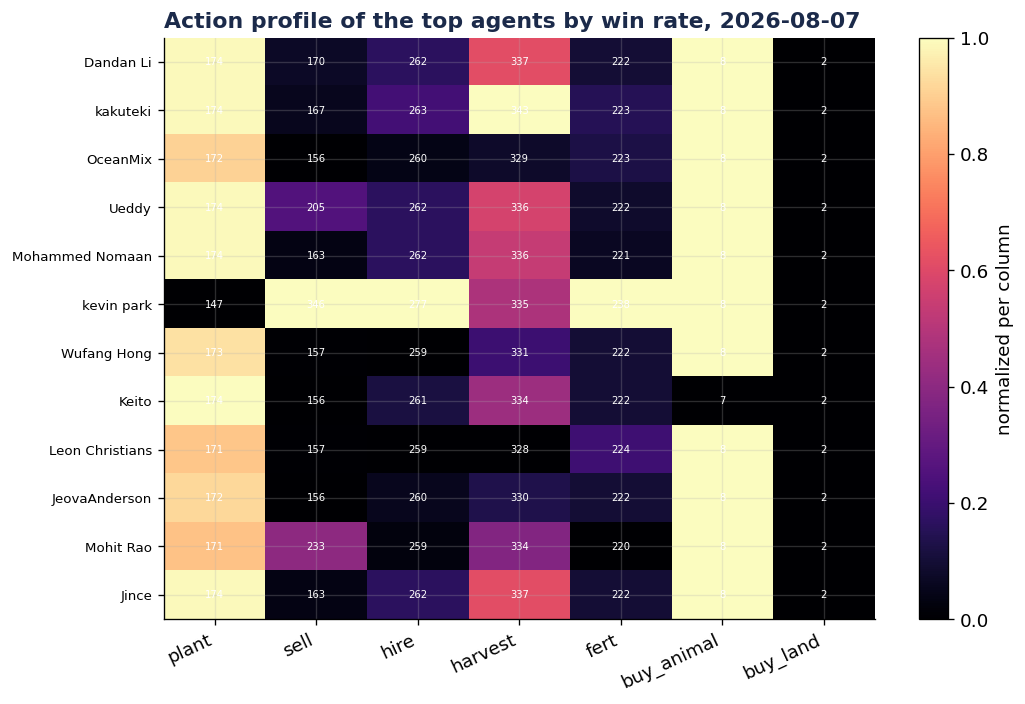

In [8]:
prof_all = sides.groupby("agent")[FEAT]
counts = sides.groupby("agent").size()
keep = counts[counts >= MIN_G].index
prof = prof_all.mean().loc[keep]
wr_by = sides.groupby("agent")["win"].mean().loc[keep]
prof = prof.loc[wr_by.sort_values(ascending=False).index].head(12)
if len(prof) >= 2:
    pn = (prof - prof.min()) / (prof.max() - prof.min() + 1e-9)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.5*len(prof))))
    im = ax.imshow(pn.values, cmap="magma", aspect="auto")
    ax.set_xticks(range(len(FEAT)), FEAT, rotation=25, ha="right")
    ax.set_yticks(range(len(prof)), [a[:22] for a in prof.index], fontsize=8)
    for i in range(len(prof)):
        for j in range(len(FEAT)):
            ax.text(j, i, f"{prof.values[i,j]:.0f}", ha="center", va="center", color="w", fontsize=6)
    fig.colorbar(im, ax=ax, label="normalized per column")
    ax.set_title(f"Action profile of the top agents by win rate, {DAY}", color=INK, loc="left", fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("too few qualifying agents for the fingerprint (renders on the full daily dump)")

## 6. Winning profit versus losing profit

The final season profit of every winning side against every losing side. If the distributions barely
separate, the game is close and the ladder is decided at the margin, not by blowouts.

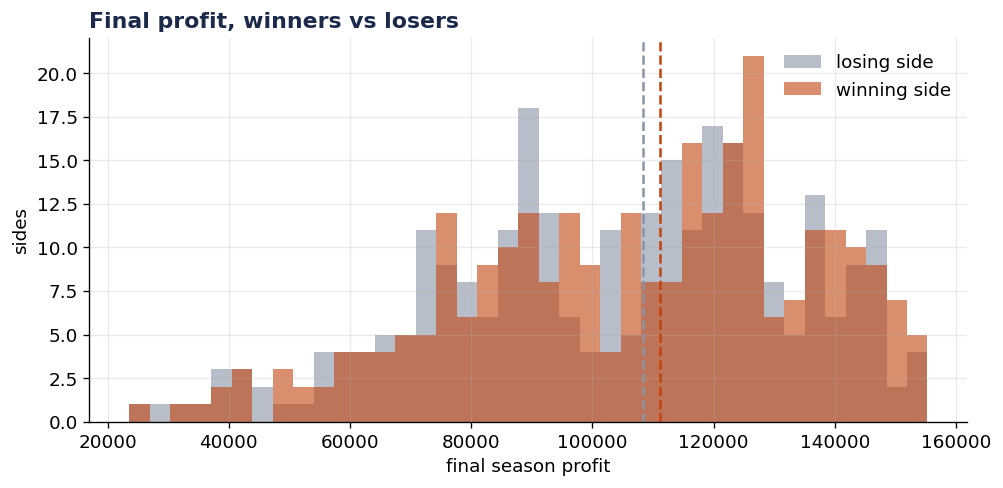

median profit  winners 111063  losers 108375  gap 2688


In [9]:
ws = sides[sides.win == 1].score; los = sides[sides.win == 0].score
if len(ws) and len(los):
    bins = np.linspace(min(ws.min(), los.min()), max(ws.max(), los.max()), 40)
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.hist(los, bins=bins, alpha=0.6, label="losing side", color=MUT)
    ax.hist(ws, bins=bins, alpha=0.6, label="winning side", color=ACC)
    ax.axvline(ws.median(), color=ACC, ls="--"); ax.axvline(los.median(), color=MUT, ls="--")
    ax.set_xlabel("final season profit"); ax.set_ylabel("sides"); ax.legend(frameon=False)
    ax.set_title("Final profit, winners vs losers", color=INK, loc="left", fontweight="bold")
    plt.tight_layout(); plt.show()
    print("median profit  winners", round(ws.median()), " losers", round(los.median()),
          " gap", round(ws.median()-los.median()))

## 7. What actually correlates with winning

The linear correlation between each action count, final profit, and the win flag, plus the selling versus
profit scatter behind it. Correlation is not cause, both sides play all 720 turns, but it shows which levers
move together on this day.

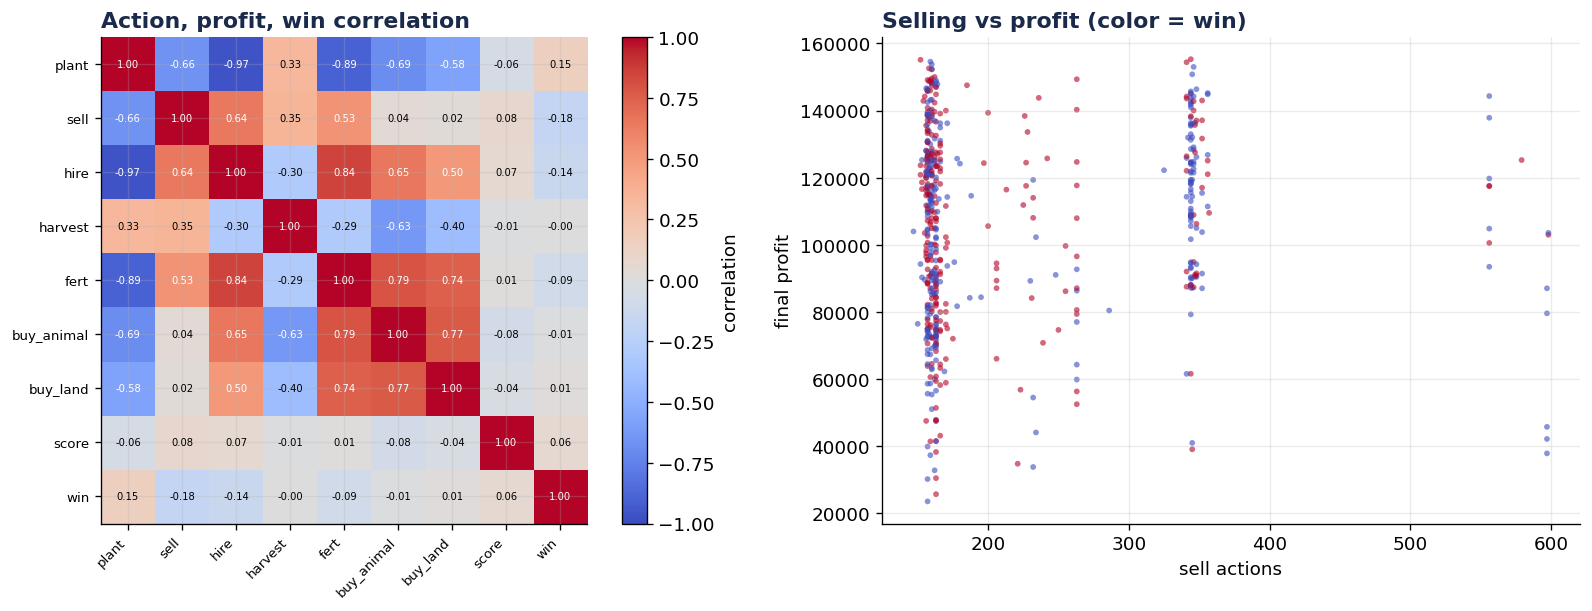

In [10]:
C = sides[FEAT + ["score", "win"]].corr()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2))
im = a1.imshow(C.values, cmap="coolwarm", vmin=-1, vmax=1)
a1.set_xticks(range(len(C)), C.columns, rotation=45, ha="right", fontsize=8)
a1.set_yticks(range(len(C)), C.columns, fontsize=8)
for i in range(len(C)):
    for j in range(len(C)):
        a1.text(j, i, f"{C.values[i,j]:.2f}", ha="center", va="center", fontsize=6,
                color="w" if abs(C.values[i,j]) > 0.5 else "k")
fig.colorbar(im, ax=a1, label="correlation")
a1.set_title("Action, profit, win correlation", color=INK, loc="left", fontweight="bold")
a2.scatter(sides.sell, sides.score, c=sides.win, cmap="coolwarm", s=12, alpha=0.6, edgecolor="none")
a2.set_xlabel("sell actions"); a2.set_ylabel("final profit")
a2.set_title("Selling vs profit (color = win)", color=INK, loc="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 8. The top three agents, side by side

The action fingerprint of the three highest win rate agents on a shared radar, each axis normalized to the
field maximum. This is the closest a static read gets to seeing distinct playstyles.

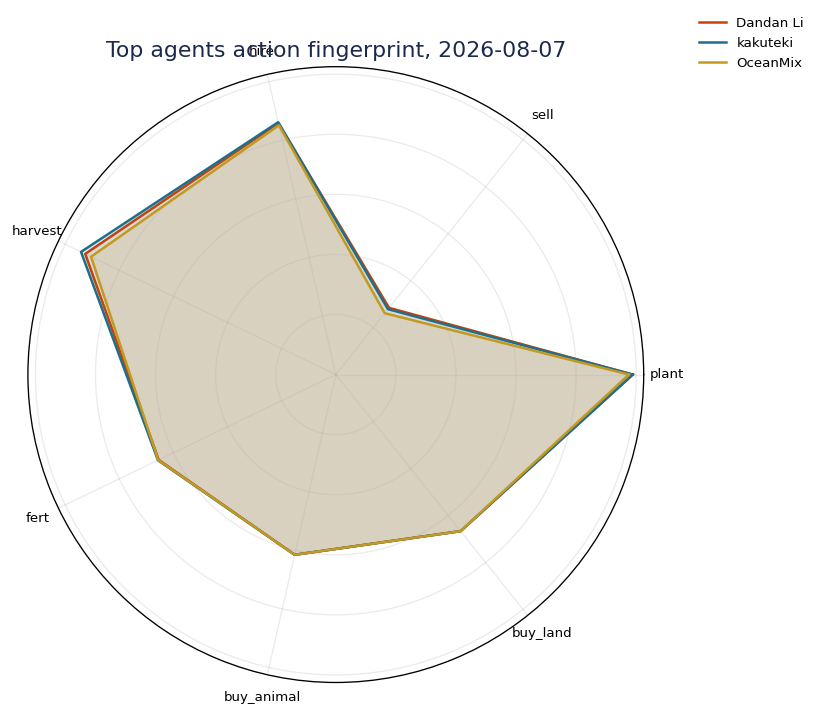

top 3 by win rate: ['Dandan Li', 'kakuteki', 'OceanMix']


In [11]:
keep = counts[counts >= MIN_G].index
wr3 = sides[sides.agent.isin(keep)].groupby("agent")["win"].mean().sort_values(ascending=False)
top3 = wr3.head(3).index.tolist()
prof2 = sides.groupby("agent")[FEAT].mean()
mx = prof2.max() + 1e-9
if len(top3) >= 1:
    ang = np.linspace(0, 2*np.pi, len(FEAT), endpoint=False).tolist(); ang += ang[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    cols = [ACC, ACC2, GD]
    for k, a in enumerate(top3):
        v = (prof2.loc[a] / mx).values.tolist(); v += v[:1]
        ax.plot(ang, v, color=cols[k % 3], label=a[:20]); ax.fill(ang, v, color=cols[k % 3], alpha=0.12)
    ax.set_xticks(ang[:-1], FEAT, fontsize=8); ax.set_yticklabels([])
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1), frameon=False, fontsize=8)
    ax.set_title(f"Top agents action fingerprint, {DAY}", color=INK)
    plt.tight_layout(); plt.show()
    print("top 3 by win rate:", top3)

## Honest scope, and how to use it

This is one day of ladder replays, so read it as a snapshot, not a law; fork it onto another day to see what
moves. Each replay is about 25MB, so I read a seeded random sample of at most 300 games of the day, not the
full dump; the parse cell prints exactly how many went in. The winner is the side with the higher final
profit, straight from the replay rewards. Ties and unfinished games are dropped. The strategy counts are the
raw action tallies over the 720 turn season, a faithful count of what each side did, not a judgement of why.
Everything is recomputed from the logs when you run the notebook, with no pasted numbers and no leaderboard
claim, so you can trust it as far as the parse, which is all shown above.

If you want the same live-from-raw-logs read for a different competition, the companion tracker
[What actually wins on the ladder](https://www.kaggle.com/code/busyaprime/what-actually-wins-on-the-ladder)
does this for the Pokemon TCG battle meta, and
[Which open Kaggle competition still has room](https://www.kaggle.com/code/busyaprime/which-open-kaggle-competition-still-has-room)
tracks every open competition worth entering.